## historical wheather data during FEBRUARY/MARCH

##### precipitation_sum (mm)	temperature_2m_mean (°C)	wind_speed_10m_max (km/h)	wind_direction_10m_dominant (°)

In [6]:
%matplotlib widget
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Percorso della cartella contenente i file CSV
folder_path = "/Users/filippomichelon/Documents/PersonalCode-local-utils/patagonia-trip-utils/openmeteo_data"

# Trova tutti i file CSV nella cartella
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Lista per contenere i DataFrame temporanei
dfs = []

# Leggi ciascun file CSV e aggiungilo alla lista
for file in csv_files:
    # Estrai il nome del file senza estensione
    filename = os.path.splitext(os.path.basename(file))[0]

    # Estrai città, latitudine e longitudine dal nome del file
    parts = filename.split("_")
    city = "_".join(parts[:-2])  # tutti i pezzi tranne gli ultimi due
    latitude = float(parts[-2])
    longitude = float(parts[-1])

    # Leggi il CSV
    df_temp = pd.read_csv(file, sep=";")

    # Aggiungi le colonne con info del file
    df_temp["city"] = city
    df_temp["latitude"] = latitude
    df_temp["longitude"] = longitude

    # Aggiungi alla lista
    dfs.append(df_temp)

# Unisci tutti i DataFrame in uno solo
df = pd.concat(dfs, ignore_index=True)


# select only days of interest: I travelled from 2025-02-10 to 2025-03-04

In [7]:
# Converte la colonna 'time' in datetime 
df["time"] = pd.to_datetime(df["time"])

# Crea una colonna temporanea con mese e giorno
df["mmdd"] = df["time"].dt.strftime("%m-%d")
df["year"] = df["time"].dt.year

# Filtra solo le date tra 10-02 e 12-31 oppure tra 01-01 e 03-04
df_season = df[(df["mmdd"] >= "02-10") & (df["mmdd"] <= "03-04")].copy()

# resetta l'indice
df_season.reset_index(drop=True, inplace=True)

df_season

,time,rain,temp,wind_speed,wind_dir,city,latitude,longitude,mmdd,year
0,1941-02-10,0.0,15.4,13.3,228,PuertoMontt,-41.472717,-72.935555,02-10,1941
1,1941-02-11,0.6,13.7,13.3,271,PuertoMontt,-41.472717,-72.935555,02-11,1941
2,1941-02-12,0.1,14.4,12.6,295,PuertoMontt,-41.472717,-72.935555,02-12,1941
3,1941-02-13,7.5,13.3,10.1,300,PuertoMontt,-41.472717,-72.935555,02-13,1941
4,1941-02-14,0.0,13.4,21.7,189,PuertoMontt,-41.472717,-72.935555,02-14,1941
...,...,...,...,...,...,...,...,...,...,...
7899,2025-02-28,0.7,10.5,17.2,314,Villa_O_Higgings,-48.459596,-72.560850,02-28,2025
7900,2025-03-01,16.7,10.8,9.3,349,Villa_O_Higgings,-48.459596,-72.560850,03-01,2025
7901,2025-03-02,20.8,8.6,10.2,337,Villa_O_Higgings,-48.459596,-72.560850,03-02,2025
7902,2025-03-03,31.5,5.4,11.0,332,Villa_O_Higgings,-48.459596,-72.560850,03-03,2025


##### imagesc with temperature of all years

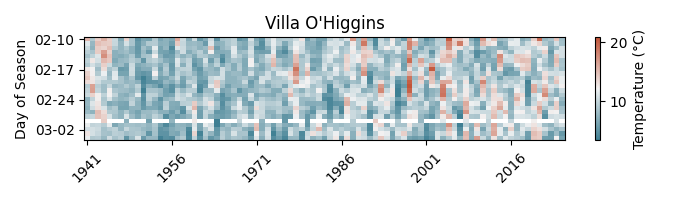

In [8]:
# 1. Calcola la media giornaliera per city + year + mmdd
df_daymean = df_season.groupby(["city", "year", "mmdd"])["temp"].mean().reset_index()

# 2. Crea un dizionario di matrici, una per ogni città
matrices = {
    city: group.pivot(index="year", columns="mmdd", values="temp")
    for city, group in df_daymean.groupby("city")
}

c = sns.diverging_palette(220, 20, as_cmap=True)
#c = sns.color_palette("cubehelix", as_cmap=True)
# Estrai la matrice
matrix = matrices["Villa_O_Higgings"]


plt.figure(figsize= (7,2))
im = plt.imshow(matrix.T, cmap = c,aspect='auto')
plt.title('Villa O\'Higgins')

plt.colorbar(im, label="Temperature (°C)")  # or use another label as needed


# Etichette assi
plt.ylabel("Day of Season")

# Tick personalizzati (opzionale)
# Estrai la matrice

# Mostra un'etichetta ogni 2 anni
plt.xticks(
    ticks=range(0, len(matrix.index), 15),
    labels=matrix.index[::15],  # ogni due anni
    rotation=45
)
plt.yticks(ticks=range(0, len(matrix.columns), 7),
           labels=[matrix.columns[i] for i in range(0, len(matrix.columns), 7)]
)

plt.tight_layout()

### wind speed plot here

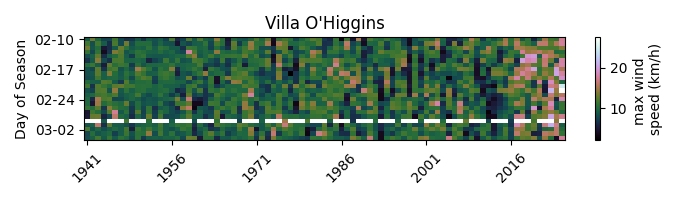

In [16]:
# 1. Calcola la media giornaliera per city + year + mmdd
df_daymean = df_season.groupby(["city", "year", "mmdd"])["wind_speed"].mean().reset_index()

# 2. Crea un dizionario di matrici, una per ogni città
matrices = {
    city: group.pivot(index="year", columns="mmdd", values="wind_speed")
    for city, group in df_daymean.groupby("city")
}

c = sns.diverging_palette(220, 20, as_cmap=True)
c = sns.color_palette("cubehelix", as_cmap=True)
# Estrai la matrice
matrix = matrices["Villa_O_Higgings"]


plt.figure(figsize= (7,2))
im = plt.imshow(matrix.T, cmap = c,aspect='auto')
plt.title('Villa O\'Higgins')

plt.colorbar(im, label="max wind \nspeed (km/h)")  # or use another label as needed


# Etichette assi
plt.ylabel("Day of Season")

# Tick personalizzati (opzionale)
# Estrai la matrice

# Mostra un'etichetta ogni 2 anni
plt.xticks(
    ticks=range(0, len(matrix.index), 15),
    labels=matrix.index[::15],  # ogni due anni
    rotation=45
)
plt.yticks(ticks=range(0, len(matrix.columns), 7),
           labels=[matrix.columns[i] for i in range(0, len(matrix.columns), 7)]
)

plt.tight_layout()